In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Einführung in Seaborn

Seaborn ist eine Pythonbibliothek zur statistischen Datenvisualisierung, die auf Matplotlib aufbaut und besonders gut mit pandas DataFrames zusammenarbeitet. Sie bietet eine hohe Abstraktionsebene und integriert statistische Elemente direkt in die Plots. Ich lasse einen Datenframe erstellen, um damit zu arbeiten:

In [13]:
data = {
    'Alter': np.random.normal(35, 8, 80).astype(int),
    'Gehalt': np.random.normal(55000, 12000, 80).astype(int),
    'Abteilung': np.random.choice(['IT', 'Marketing', 'Finanz', 'HR'], 80),
    'Erfahrung': np.random.randint(1, 20, 80),
    'Geschlecht': np.random.choice(['m', 'w'], 80)
}

df = pd.DataFrame(data)
print(df)

    Alter  Gehalt  Abteilung  Erfahrung Geschlecht
0      48   43775     Finanz         15          w
1      33   44021  Marketing         17          w
2      39   55232         IT          8          m
3      41   41110         HR         15          w
4      31   64838  Marketing         17          m
..    ...     ...        ...        ...        ...
75     29   54429         HR         19          m
76     29   39107         HR         11          w
77     23   26994         HR          3          m
78     29   50659  Marketing          8          w
79     26   57767  Marketing         16          m

[80 rows x 5 columns]


Um ein einfaches Streudiagramm in Abhängigkeit von ALter und Gehalt zu erstellen, genügt der Code:

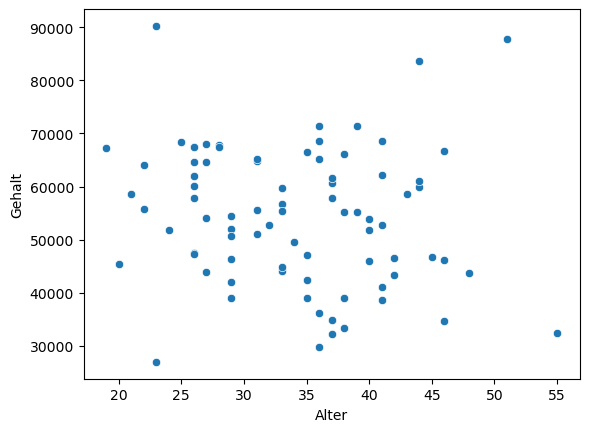

In [14]:
sns.scatterplot(data=df, x="Alter", y="Gehalt")
plt.show()

Um ein Balkendiagramm der Häufigkeiten des Geschlechts zu erstellen, genügt:

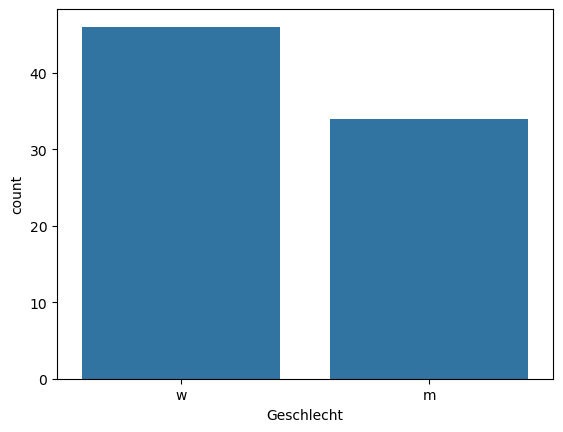

In [15]:
sns.countplot(data=df, x="Geschlecht")
plt.show()

## Tidy vs Untidy Datensätze

Tidy Daten liegen vor, wenn jede Variable eine eigene Spalte bildet, jede Beobachtung (jeder Fall) eine eigene Zeile darstellt und jede Zelle genau einen Wert enthält. In diesem Format ist jede Information klar getrennt und strukturiert. Seaborn, pandas und die meisten modernen Visualisierungs- und Analysebibliotheken arbeiten am besten und einfachsten mit tidy Daten. Funktionen wie `hue=`, `style=` oder `col=` können direkt auf Spalten zugreifen, ohne dass vorher umgeformt werden muss.

Untidy Daten liegen hingegen vor, wenn Werte einer Variablen über mehrere Spalten verteilt sind. Häufig stehen Kategorien als Spaltenüberschriften (z. B. `Gehalt_IT`, `Gehalt_Marketing`, `Gehalt_Finanz`) oder Messwerte zu verschiedenen Zeitpunkten sind in separaten Spalten abgelegt. Solche Daten sind für Menschen manchmal übersichtlicher, aber für Seaborn und statistische Auswertungen unpraktisch, da viele Funktionen nicht direkt damit arbeiten können.

In [16]:
# Tidy Datensatz
tidy_data = pd.DataFrame({
    'Mitarbeiter': [1, 2, 3, 4, 5, 6],
    'Abteilung': ['IT', 'IT', 'Marketing', 'Marketing', 'Finanz', 'Finanz'],
    'Geschlecht': ['m', 'w', 'm', 'w', 'm', 'w'],
    'Gehalt': [62000, 58000, 51000, 49000, 67000, 64000],
    'Alter': [34, 29, 41, 38, 45, 36]
})

print(tidy_data)

   Mitarbeiter  Abteilung Geschlecht  Gehalt  Alter
0            1         IT          m   62000     34
1            2         IT          w   58000     29
2            3  Marketing          m   51000     41
3            4  Marketing          w   49000     38
4            5     Finanz          m   67000     45
5            6     Finanz          w   64000     36


In [17]:
# Untidy Datensatz
untidy_data = pd.DataFrame({
    'Mitarbeiter': [1, 2, 3, 4, 5, 6],
    'Gehalt_IT': [62000, 58000, None, None, None, None],
    'Gehalt_Marketing': [None, None, 51000, 49000, None, None],
    'Gehalt_Finanz': [None, None, None, None, 67000, 64000],
    'Alter': [34, 29, 41, 38, 45, 36]
})

print(untidy_data)

   Mitarbeiter  Gehalt_IT  Gehalt_Marketing  Gehalt_Finanz  Alter
0            1    62000.0               NaN            NaN     34
1            2    58000.0               NaN            NaN     29
2            3        NaN           51000.0            NaN     41
3            4        NaN           49000.0            NaN     38
4            5        NaN               NaN        67000.0     45
5            6        NaN               NaN        64000.0     36


## Die `hue=` Funktion

Die `hue` Funktion erlaubt es, eine zusätzliche kategoriale Variable farblich in den Plot einzubringen. Dadurch werden Gruppen innerhalb der Daten automatisch farblich unterschieden. Im folgenden Beispiel kann man durch `hue="Abteilung"` das Streudiagramm in Abhängigkeit von ALter und Gehalt nach Abteilungen (jeweils eigene Farben) aufspalten bzw. kategorisch sichtbar machen. 

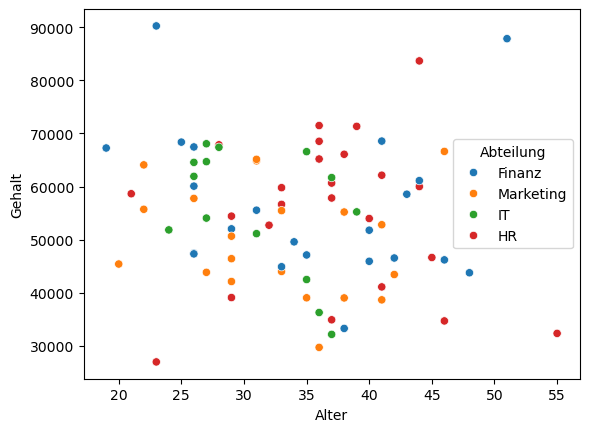

In [18]:
sns.scatterplot(
    data=df,
    x='Alter',
    y='Gehalt',
    hue='Abteilung'         
)
plt.show()

Mit den Funktionen `palette` und `hue_order`lassen sich zum einen die dargestellten Farben, als auch die Reihenfolge der Farben steuern. Dies geschieht in der Form von Listen oder pandas Daten. Es gibt auch vorprogrammierte Sets für die Ordnung der Farben (z.B. `palette` = 'Set1')

<Axes: xlabel='Alter', ylabel='Gehalt'>

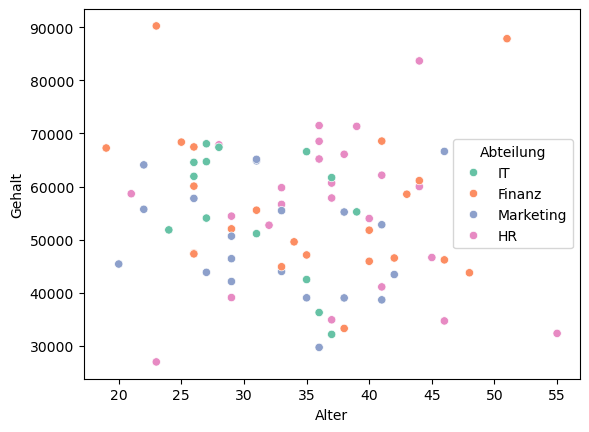

In [19]:
sns.scatterplot(
    data=df,
    x='Alter',
    y='Gehalt',
    hue='Abteilung',
    hue_order=['IT', 'Finanz', 'Marketing', 'HR'],   # gewünschte Reihenfolge
    palette='Set2'
)

# Visualisierungen von 2 quantitativen Variablen

Relational Plots zeigen Beziehungen zwischen zwei numerischen Variablen, wie im vorherigen Kapitel die Beziehung zwischen Gehalt und Alter oder auch die Beziehung zwischen Größe und Gewicht. Durch die Funktion `hue=` kann man diese Beziehungen in eine weitere Variable fablich unterscheiden. Nun soll es darum gehen, dass man die Kategorisierung wie durch die `hue=` Funktion zuvor innerhalb eines Diagrammes in 2 Plots darstellt. Solche Diagramme sind vor allem nützlich für Vergleiche.
Die wichtigste Funktion dafür ist `sns.relplot()`.

## Relational Plots und Subplots in Seaborn

Mit dem Befehl `kind='scatter'` kann man die Art des Diagramms (Streudiagramm, Liniendiagramm) festsetzen und der Befehl `col='Abteilung'` gibt an, dass die Subplots in jeweils einer eigenen Spalte (Nach Abteilung) aufgelistet werden sollen. 

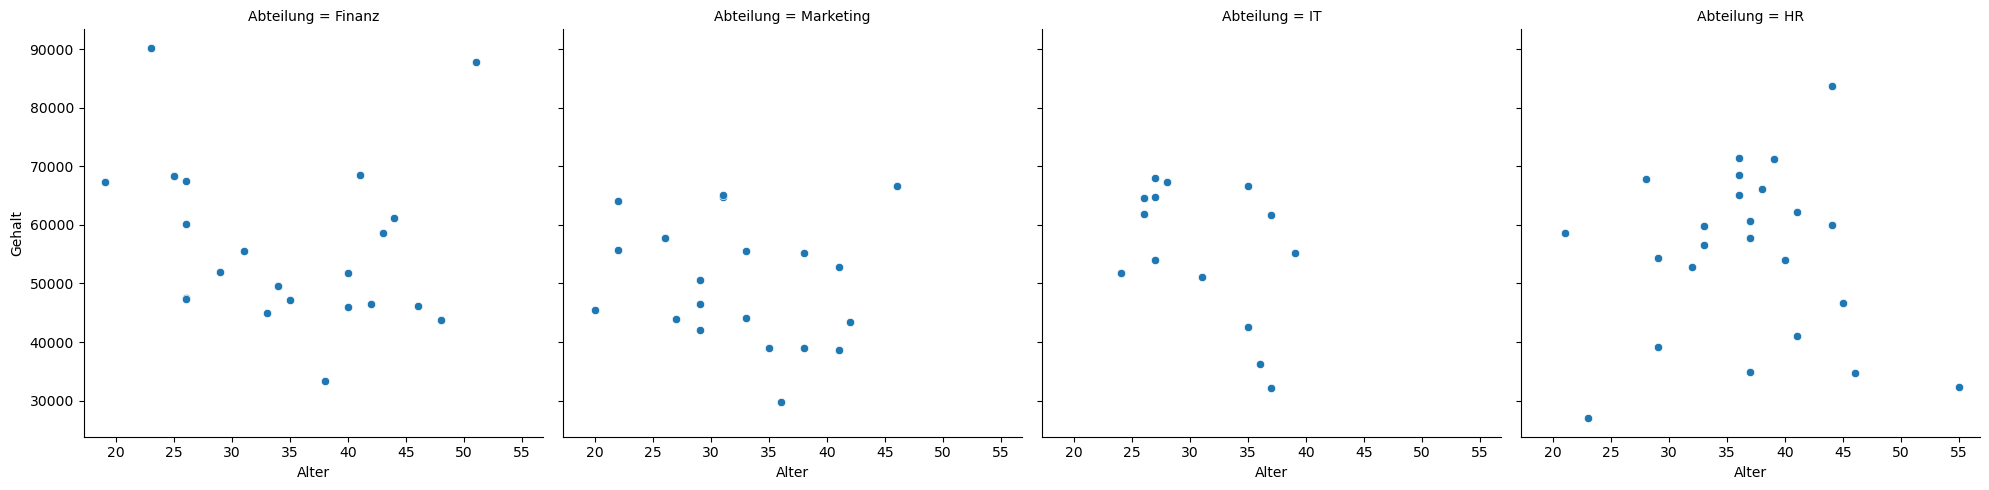

In [20]:
sns.relplot(
    data=df,
    x='Alter',
    y='Gehalt',
    kind='scatter',          
    col='Abteilung',        
)
plt.show()

Äquivalent dazu sorgt `col='Abteilung'` für eine Zeilenweise Auflistung der Subplots

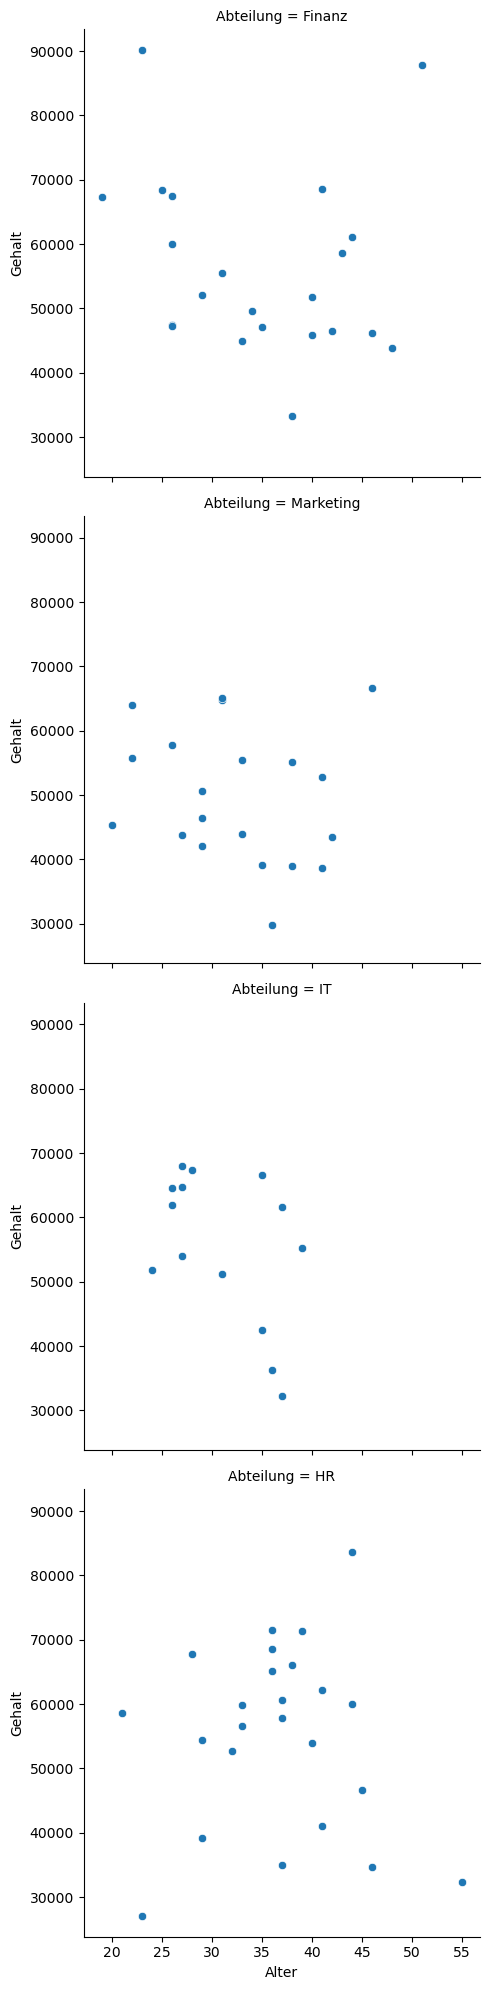

In [21]:
sns.relplot(
    data=df,
    x='Alter',
    y='Gehalt',
    kind='scatter',          
    row='Abteilung',        
)
plt.show()

(Fortsetzung folgt)